In [33]:
import numpy as np
import matplotlib.pyplot as plt
import astroML.stats

## Markov Chain

In [34]:
def weather(a):
    if a==1:
        a=np.random.randint(0,2,1)
        return a
    if a==0:
        c=np.random.randint(0,10,1)
        if c==0:
            a=1
        return a

In [35]:
N=10000
w=np.array([])
p=np.array([])
a=1
np.random.seed(3)
for i in range(N):
    w=np.append(w,a)
    p=np.append(p,np.sum(w)/(i+1))
    a=weather(a)

### Distributions

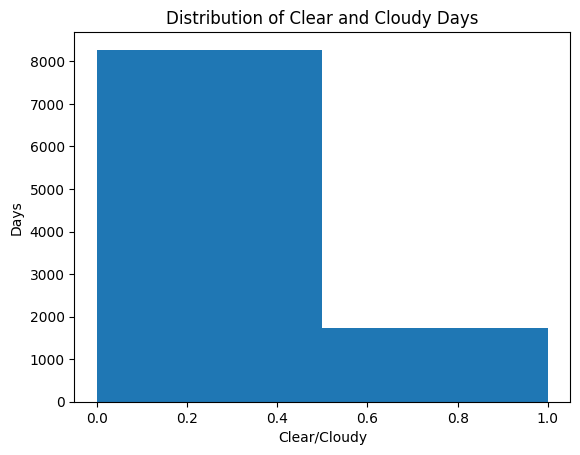

In [36]:
plt.ylabel("Days")
plt.xlabel("Clear/Cloudy")
plt.title("Distribution of Clear and Cloudy Days")
plt.hist(w, bins=2);

### Trace Plot

Probability of Cloudy weather after 10000 days: 0.1727
Probability of Clear weather after 10000 days: 0.8273


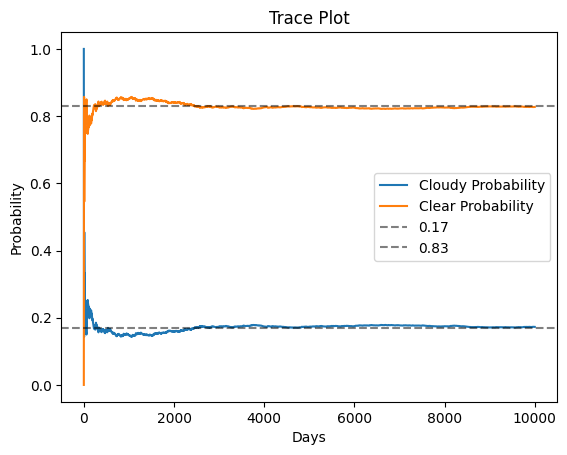

In [37]:
x=np.linspace(0,N,N)
plt.plot(x,p, label="Cloudy Probability")
plt.plot(x,1-p, label="Clear Probability")
plt.axhline(0.17, ls="--", c='k', label='0.17', alpha=0.5)
plt.axhline(0.83, ls="--", c='k', label='0.83', alpha=0.5)
print("Probability of Cloudy weather after 10000 days:", p[-1])
print("Probability of Clear weather after 10000 days:", 1-p[-1])

plt.xlabel("Days")
plt.ylabel("Probability")
plt.title("Trace Plot")
plt.legend();

### Probability Distribution

Median probability of a Cloudy day: 0.17345991360401064 and its associated error: 0.0032414460656395284
Median probability of a Clear day: 0.8265400863959893 and its associated error: 0.0032414460656395696


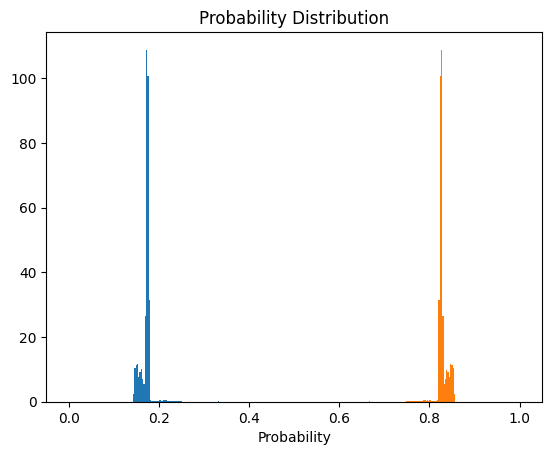

In [38]:
plt.hist(p, bins=300, density=True);
plt.hist(1-p, bins=300, density=True);
plt.xlabel("Probability");
plt.title("Probability Distribution")

print("Median probability of a Cloudy day:", np.median(p), "and its associated error:", astroML.stats.sigmaG(p))
print("Median probability of a Clear day:", np.median(1-p), "and its associated error:", astroML.stats.sigmaG(1-p))

Mean probability of a Clear day: 0.17364080403609036 and its associated error: 0.0034016692102001277
Median probability of a Cloudy day: 0.17409382097877796 and its associated error: 0.002784177182421979


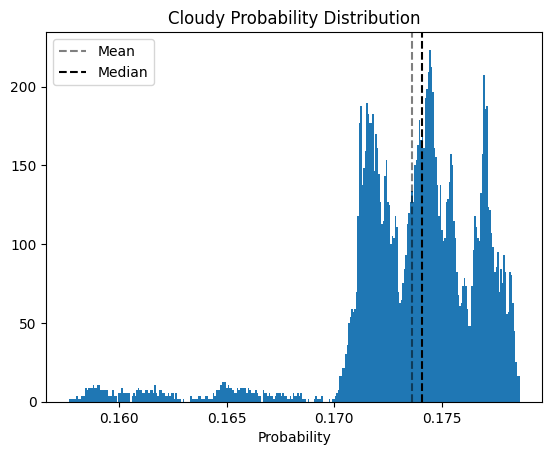

In [39]:
burn_p = p[2000:]

plt.hist(burn_p, bins=300, density=True);
plt.axvline(np.mean(burn_p), alpha=0.5, c='k', ls='--', label='Mean')
plt.axvline(np.median(burn_p), c='k', ls='--', label='Median')
plt.xlabel("Probability");
plt.title("Cloudy Probability Distribution")
plt.legend(loc='best')

print("Mean probability of a Clear day:", np.mean(burn_p), "and its associated error:", np.std(burn_p))
print("Median probability of a Cloudy day:", np.median(burn_p), "and its associated error:", astroML.stats.sigmaG(burn_p))

Mean probability of a Clear day: 0.8263591959639096 and its associated error: 0.0034016692102001277
Median probability of a Clear day: 0.8259061790212221 and its associated error: 0.0027841771824219587


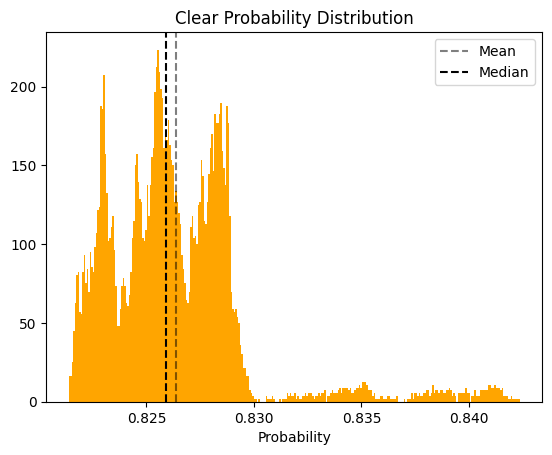

In [40]:
plt.hist(1-burn_p, bins=300, density=True, color='orange');
plt.axvline(np.mean(1-burn_p), alpha=0.5, c='k', ls='--', label='Mean')
plt.axvline(np.median(1-burn_p), c='k', ls='--', label='Median')
plt.xlabel("Probability");
plt.title("Clear Probability Distribution")
plt.legend(loc='best')

print("Mean probability of a Clear day:", np.mean(1-burn_p), "and its associated error:", np.std(1-burn_p))
print("Median probability of a Clear day:", np.median(1-burn_p), "and its associated error:", astroML.stats.sigmaG(1-burn_p))

## Burn in

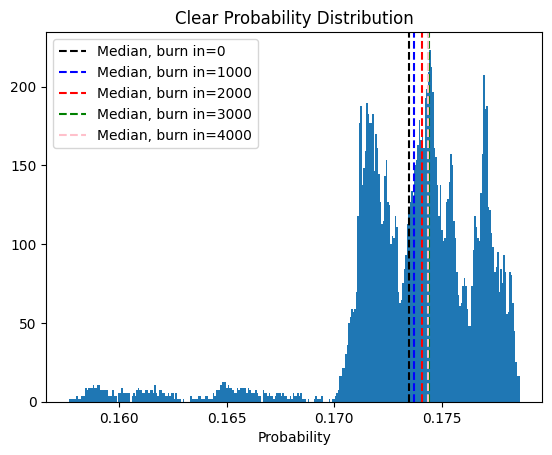

In [41]:
col=['k','b','red','green','pink']
for i in range(5):
    burn_p=p[i*1000:]
    plt.axvline(np.median(burn_p), ls='--', c=col[i], label='Median, burn in='+str(i*1000))

plt.hist(p[2000:], bins=300, density=True);
plt.xlabel("Probability");
plt.title("Clear Probability Distribution")
plt.legend(loc='best');

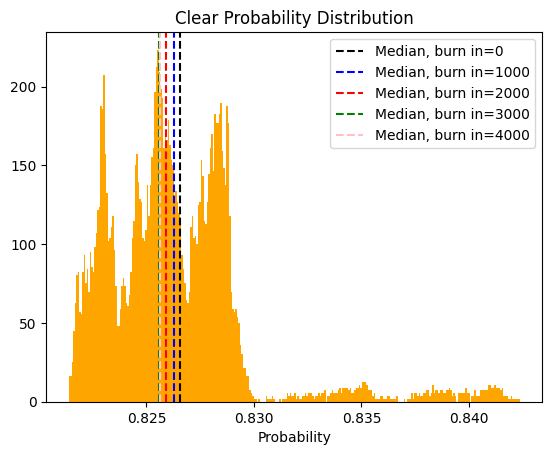

In [42]:
col=['k','b','red','green','pink']
for i in range(5):
    burn_p=p[i*1000:]
    plt.axvline(np.median(1-burn_p), ls='--', c=col[i], label='Median, burn in='+str(i*1000))

plt.hist(1-p[2000:], bins=300, density=True, color='orange');

plt.xlabel("Probability");
plt.title("Clear Probability Distribution")
plt.legend(loc='best');

### Check with 10 runs

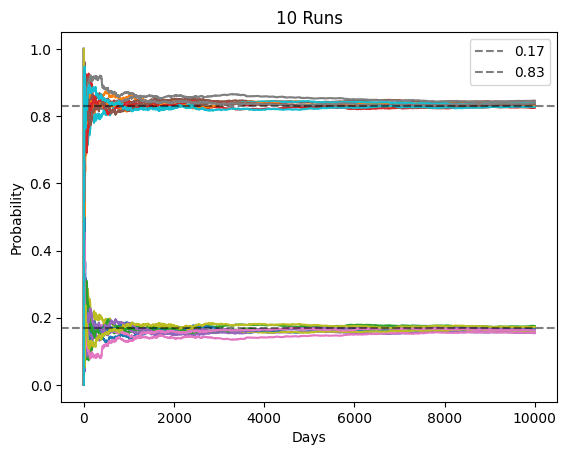

In [43]:
N=10000
x=np.linspace(0,N,N)

for j in range(10):
    w=np.array([])
    p=np.array([])
    a=1
    for i in range(N):
        w=np.append(w,a)
        p=np.append(p,np.sum(w)/(i+1))
        a=weather(a)
    plt.plot(x,p)
    plt.plot(x,1-p)


plt.axhline(0.17, ls="--", c='k', label='0.17', alpha=0.5)
plt.axhline(0.83, ls="--", c='k', label='0.83', alpha=0.5)

plt.title("10 Runs")
plt.xlabel("Days")
plt.ylabel("Probability")
plt.legend();